Preprocess Wire Data

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from microboone_utils import *
from file import File

In [27]:
f = File("/nevis/westside/data/sc5303/Data/ubOpen/h5/bnb_WithWire_00.h5")

In [45]:
tables = ['event_table','wire_table','hit_table','edep_table']
for t in tables: f.add_group(t)
f.read_data(0, 32)
evts = f.build_evt()

In [46]:
evt = evts[31]
evt_id = [evt["event_table"]["run"].iloc[0],evt["event_table"]["subrun"].iloc[0],evt["event_table"]["event"].iloc[0]]
print('Going to produce wire image for event:',evt_id)

Going to produce wire image for event: [7004, 331, 16582]


In [47]:
wires = evt["wire_table"]

In [48]:
planeadcs = [wires.query("local_plane==%i"%p)[['adc_%i'%i for i in range(0,ntimeticks())]].to_numpy() for p in range(2,3)]

In [49]:
planeadcs[0].max()

150.195

Run / Sub / Event : 7004 / 331 / 16582 - saturation set to ADC sum=100.00


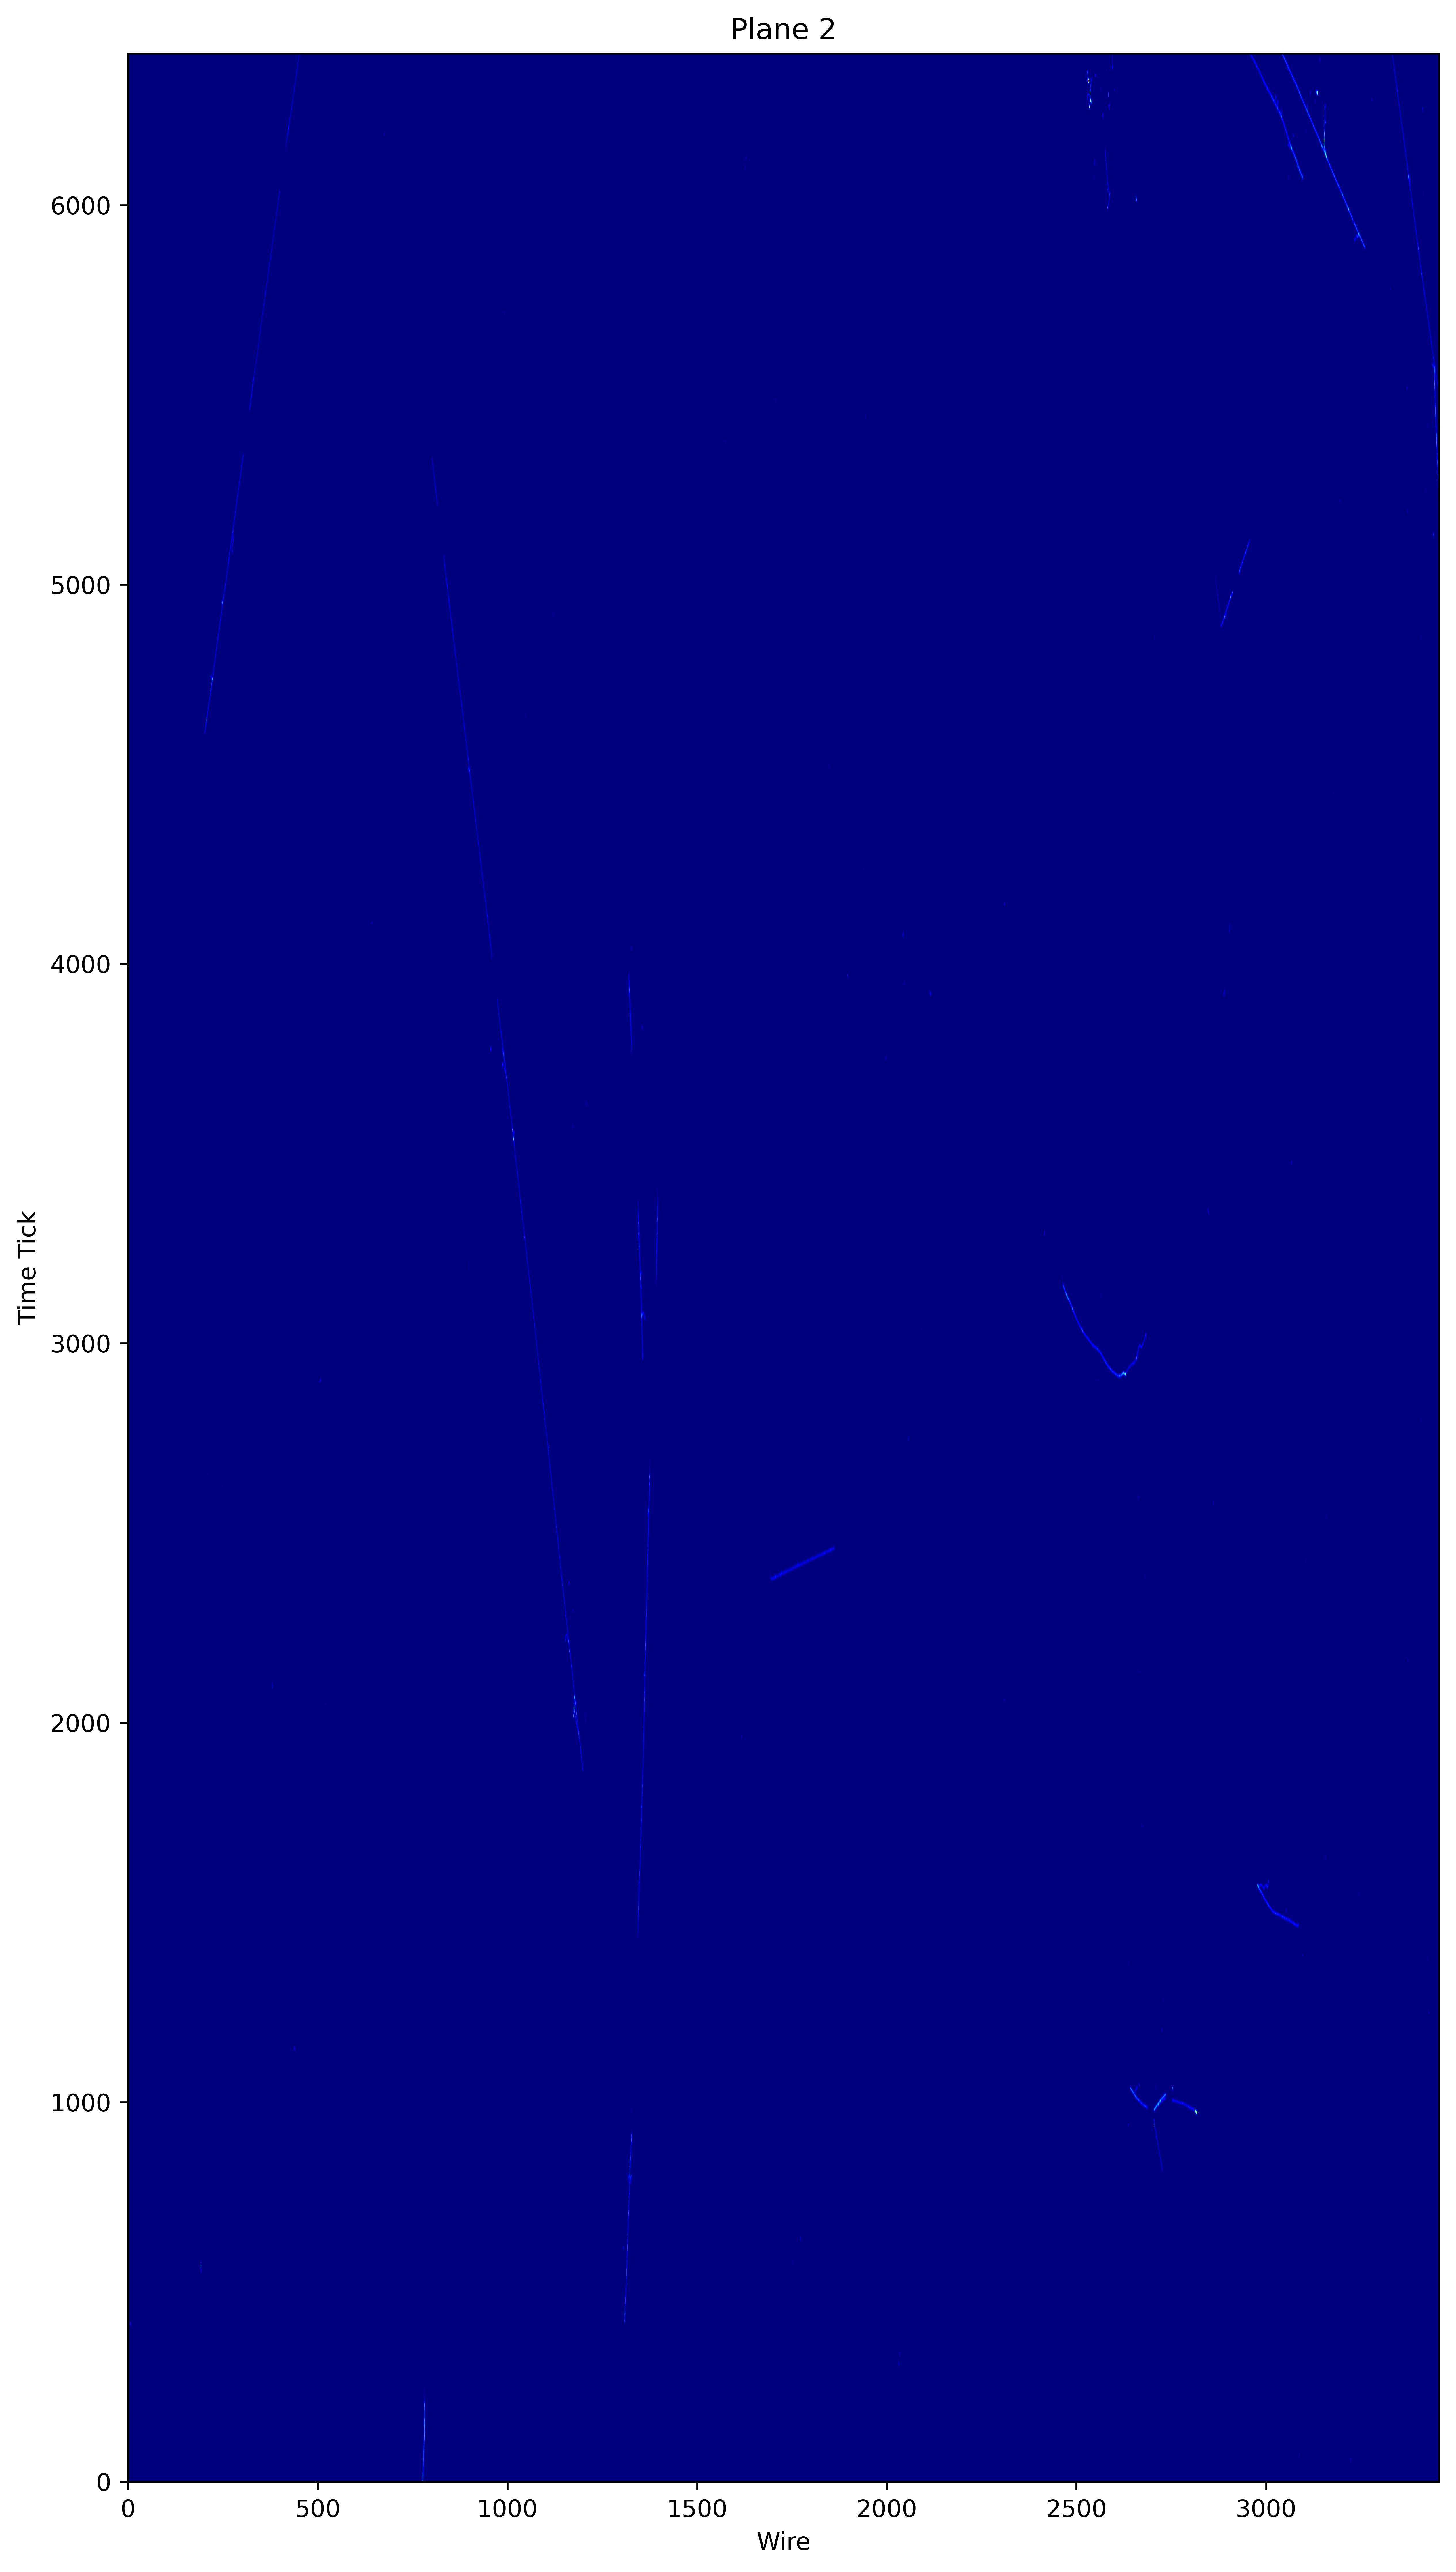

In [50]:
zmax = 100

print("Run / Sub / Event : %i / %i / %i - saturation set to ADC sum=%.2f"%(evt_id[0],evt_id[1],evt_id[2],zmax))

fig, (ax1) = plt.subplots(1, 1, figsize=(20, 15), dpi=600)

im1 = ax1.imshow(planeadcs[0].T,vmin=0,vmax=zmax,origin='lower',cmap='jet')
ax1.set_title("Plane 2")
ax1.set_xlabel("Wire")
ax1.set_ylabel("Time Tick")


plt.tight_layout()

## Extract ground truth and convert into image format

Get the ground truth from hits and energy deposition tables.

In [59]:
hits = evt["hit_table"]
edeps = evt["edep_table"]
edeps = edeps.sort_values(by=['energy_fraction'], ascending=False, kind='mergesort').drop_duplicates(["hit_id"])
hits = hits.merge(edeps, on=["hit_id"], how="left")
hits['g4_id'] = hits['g4_id'].fillna(-1)
hits = hits.fillna(0)

In [52]:
from math import floor, ceil

In [56]:
planetruth = [np.zeros(shape=(nwires(p),ntimeticks())) for p in range(2,3)]

nrms = 2
for p in range(2,3):
    nuhits = hits.query('local_plane==%i and g4_id>=0'%p)[['local_wire','local_time','rms']]
    for i,h in nuhits.iterrows():
        planetruth[0][int(h['local_wire'])][floor(h['local_time']-nrms*h['rms']):ceil(h['local_time']+nrms*h['rms'])] = 1
    cosmhits = hits.query('local_plane==%i and g4_id<0'%p)[['local_wire','local_time','rms']]
    for i,h in cosmhits.iterrows():
        planetruth[0][int(h['local_wire'])][floor(h['local_time']-nrms*h['rms']):ceil(h['local_time']+nrms*h['rms'])] = 0

for p in range(0,1):
    planetruth[p] = np.multiply(planetruth[p],planeadcs[p])

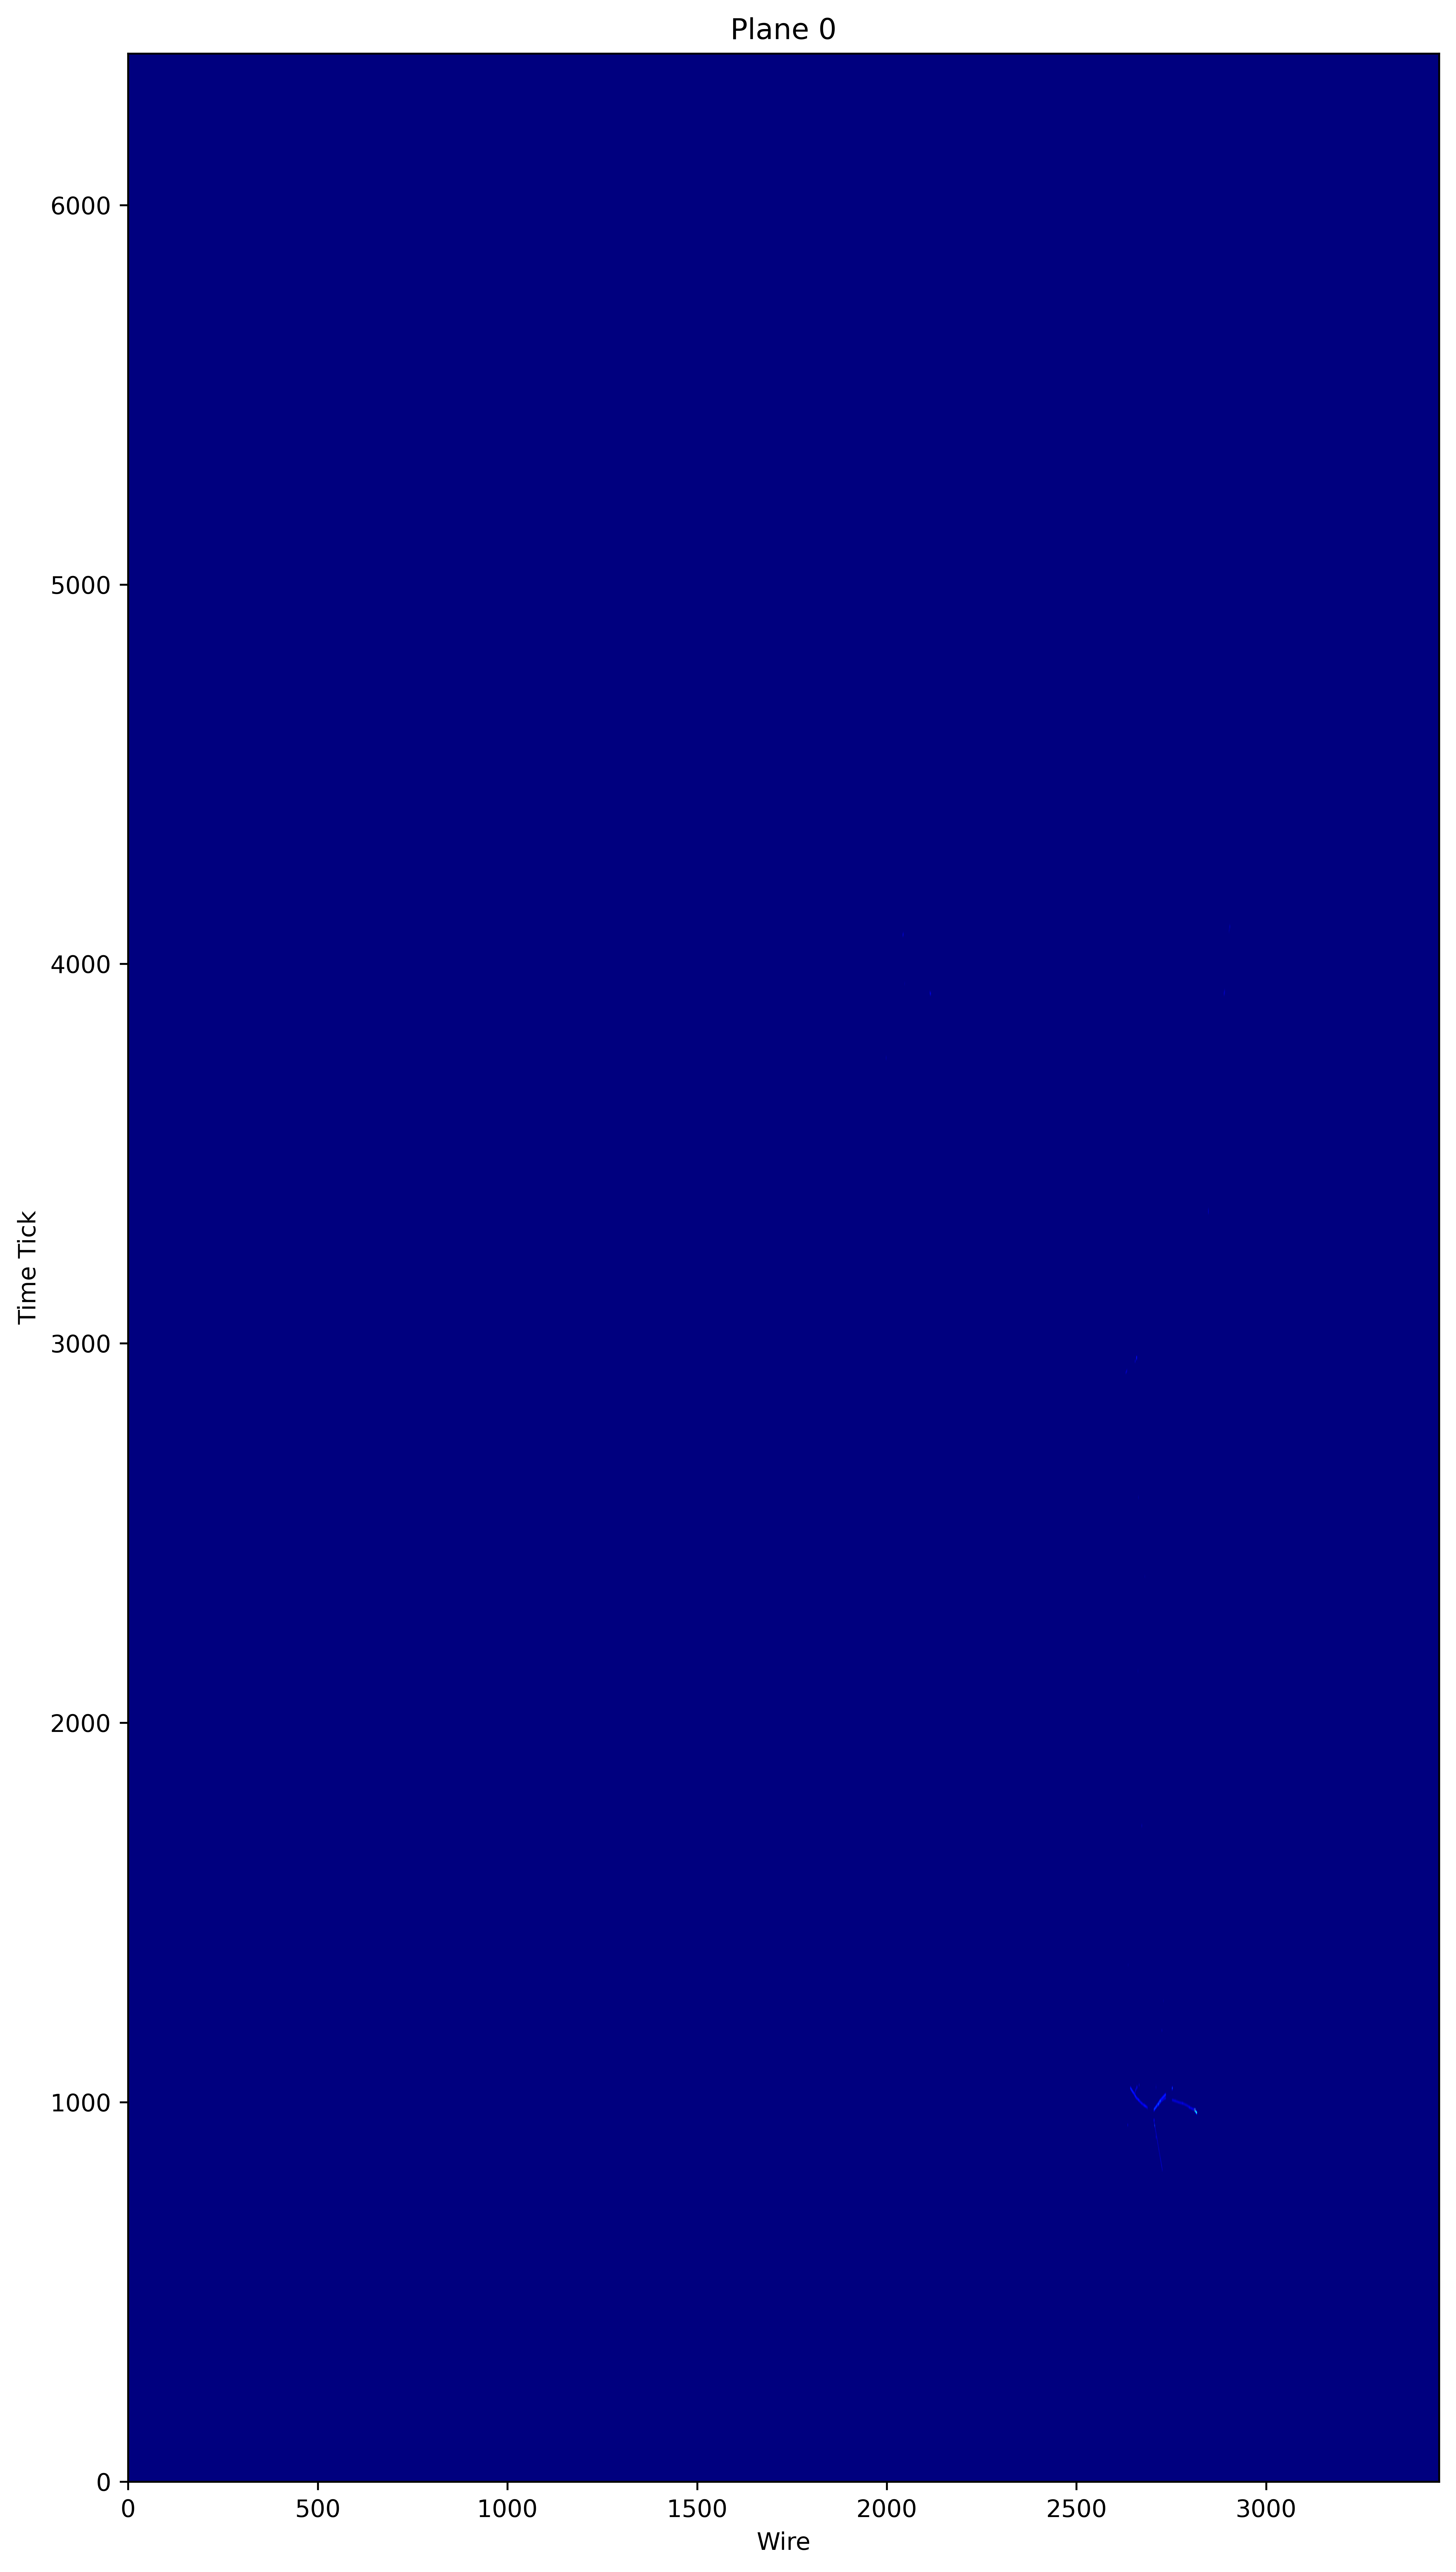

In [60]:
fig, (ax1) = plt.subplots(1, 1, figsize=(20, 15), dpi=600)



zmax = planetruth[0].max()


im1 = ax1.imshow(planetruth[0].T,vmin=0,vmax=zmax,origin='lower',cmap='jet')
ax1.set_title("Plane 0")
ax1.set_xlabel("Wire")
ax1.set_ylabel("Time Tick")

plt.tight_layout()